## D2D example: CLD on Young Adult Mental Health
In this example, we  implement a system dynamics model (SDM) analysis of a causal loop diagram (CLD) published as an example in the Education Corner article by Uleman et al (2024) doi: 10.1093/ije/dyae091. This CLD focuses on the feedback loops between sleep and depressive symptoms in young adults.

In Kumu, the diagram looks as follows:

<img src="Sleep CLD.jpg" alt="drawing" width="500"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [1]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Sleep"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

double_factor_interventions_setting = False # Specify whether to use double factor interventions

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings(double_factor_interventions_setting)  # Extract the settings using the Kumu Excel file
s.double_factor_interventions = True # Default to single factor interventions #TODO now doesn't work well

# Set simulation settings
s.seed = 1912884
s.N = 200  # Number of simulations
s.t_end = 12  # Timeframe of the simulation
s.time_unit = "Months"  # Base unit of time (time unit of t_end and dt)
s.parameter_value_aux = 0.1  # Max range for uniform, SD for halfnormal
s.parameter_value_stocks = 0.1   # Max range for uniform, SD for halfnormal

sdm = SDM(s)  # Load the module for formulating and simulating the SDM



Variable of interest: Depressive symptoms
with 7 intervention variables

20 feedback loops of maximum length 5
All loops have at least one stock
Solving an SDM with interaction terms.
Two-factor interventions will be simulated by default, unless specified otherwise using s.double_factor_interventions = False


Given these settings, we can now run simulations from the SDM-converted CLD.

In [2]:
df_sol, param_samples = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

Running Simulations: 100%|██████████| 200/200 [00:02<00:00, 80.68it/s]


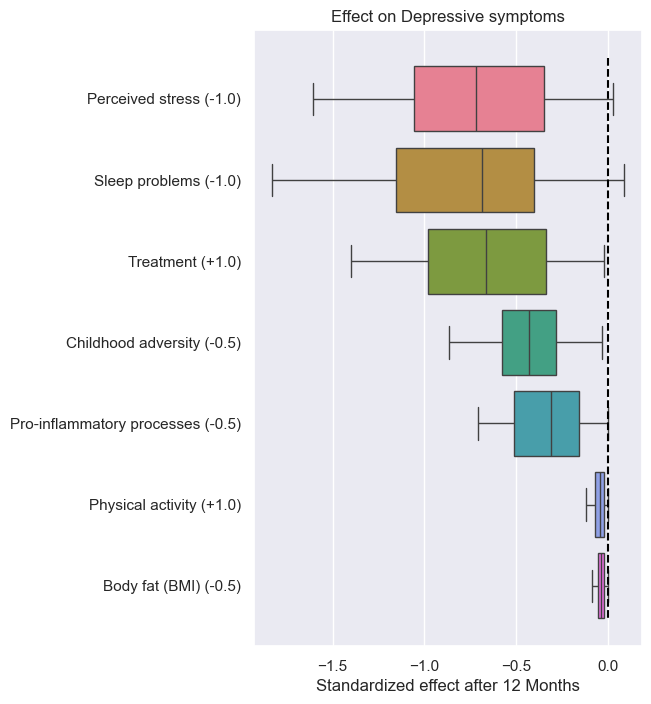

In [3]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi],
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

In [4]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")


---- Variable of Interest:  Depressive symptoms

Comparison Table (Percentage Greater, 95% CI, Cliff’s Delta):
+----------------------------+----------------------------+-------------+----------------------+-----------------+
| Intervention A             | Intervention B             |   % Greater | 95% CI (% Greater)   |   Cliff's Delta |
+============================+============================+=============+======================+=================+
| Perceived stress           | Sleep problems             |        45.5 | [39.0, 52.0]         |           -0.09 |
+----------------------------+----------------------------+-------------+----------------------+-----------------+
| Perceived stress           | Treatment                  |        55   | [49.0, 62.0]         |            0.1  |
+----------------------------+----------------------------+-------------+----------------------+-----------------+
| Perceived stress           | Childhood adversity        |        75   | [69.5, 81.

## Sensitivity analysis

In [5]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.1 # 0.05
int_var = None #"Sleep_problems" #None  # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
#for int_var in s.intervention_variables:
    print("---- Variable of Interest: ", voi)
    #print("---- Intervention Variable: ", int_var)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")

---- Variable of Interest:  Depressive symptoms
+-------------------------------------------------+--------------------+--------------------+--------------+-----------------------------------+---------------------------------+
|                    Variable                     | Global Correlation | 95% CI (bootstrap) |   p-value    | Mean Correlation per Intervention | SD Correlation per Intervention |
+-------------------------------------------------+--------------------+--------------------+--------------+-----------------------------------+---------------------------------+
|      Perceived stress->Depressive symptoms      |        0.2         |        0.0         | [0.15, 0.25] |               0.31                |               0.3               |
| Pro-inflammatory processes->Depressive symptoms |        0.17        |        0.0         | [0.11, 0.22] |               0.34                |              0.35               |
|       Sleep problems->Depressive symptoms       |      